<a href="https://colab.research.google.com/github/WVF-1/Signal-Simulation/blob/main/eda_of_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pittsburgh Traffic Flow, Project 4: EDA on the Simulation Results

**Newsletter series: Geospatial Data & Public Transportation — Project 4 of 5 (EDA on simulation output)**

A light pass over what the fixed-timing simulation actually produced. Two questions worth answering with a chart, both standard traffic-engineering framings rather than generic time-series plots:

1. **What does congestion look like within a single signal cycle, on average?** (the classic queue-buildup/discharge "sawtooth" pattern)
2. **Does the 80/20 green-ratio fix at the post-merge intersections actually show up in the data as lower relative congestion?** -- a direct check on a design decision from the simulation notebook, not just an assumption.

**Data:** your own simulation output -- `pittsburgh_adv__sim_queue_timeseries.csv` (per-tick queue length for all 21 road segments) and `pittsburgh_adv_sim_network_definition.csv` (each intersection's approaches and green ratios).

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PGH_BLACK = "#1a1a1a"
MAINLINE_COLOR = "#c1440e"
CROSS_COLOR = "#4a6b8a"


## Upload your Project 4 exports

In [2]:
from google.colab import files

uploaded = files.upload()


Saving pittsburgh_adv_sim_network_definition.csv to pittsburgh_adv_sim_network_definition.csv
Saving pittsburgh_adv__sim_queue_timeseries.csv to pittsburgh_adv__sim_queue_timeseries.csv


In [3]:
queue_df = pd.read_csv("pittsburgh_adv__sim_queue_timeseries.csv")
network_df = pd.read_csv("pittsburgh_adv_sim_network_definition.csv")

CYCLE_LENGTH_S = 60  # matches the simulation notebook

print(f"Ticks: {len(queue_df)}   Segments: {len(queue_df.columns)}")
queue_df.head()


Ticks: 1800   Segments: 22


,forbes_entry,forbes_seg1,forbes_seg2,forbes_seg3,combined_seg1,combined_seg2,cross_grant,cross_smithfield,cross_wood,cross_stanwix,...,fifth_seg1,fifth_seg2,fifth_seg3,fifth_seg4,fifth_seg5,cross_craig,cross_bigelow,cross_bellefield,cross_halket,cross_dithridge
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Quick descriptive stats

Mean, max, and variability of queue length per segment -- the plain summary before the two charts below.

In [4]:
summary = queue_df.agg(["mean", "max", "std"]).T.sort_values("mean", ascending=False)
summary.columns = ["mean_queue", "max_queue", "std_queue"]
summary.round(2)


,mean_queue,max_queue,std_queue
cross_fortpitt,4.69,13.0,2.83
cross_stanwix,4.42,13.0,2.94
forbes_seg2,2.60,9.0,2.83
fifth_seg5,2.56,10.0,2.93
fifth_seg2,2.35,8.0,2.61
fifth_seg4,2.32,7.0,2.58
forbes_entry,2.16,11.0,2.40
forbes_seg1,1.87,10.0,2.25
forbes_seg3,1.78,6.0,2.06
fifth_entry,1.50,10.0,1.99


## Visual 1: The average signal cycle, folded

Every intersection runs on the same 60-second cycle, just offset in time from each other (the green-wave coordination from the simulation notebook). If we fold every tick's position onto "seconds into its cycle" (`tick % 60`) and average across all ~30 cycles in the run, the noise cancels out and the underlying pattern -- queue builds during red, drains during green -- should show up cleanly. This is the standard way traffic engineers visualize a signal's cyclic flow profile.

One honest simplification: this fold uses raw cycle position, not each segment's own green-wave offset (that offset wasn't in this export), so the sawtooth may look a little smoothed for offset segments rather than perfectly sharp -- the shape is still real, just not phase-aligned to the exact second.

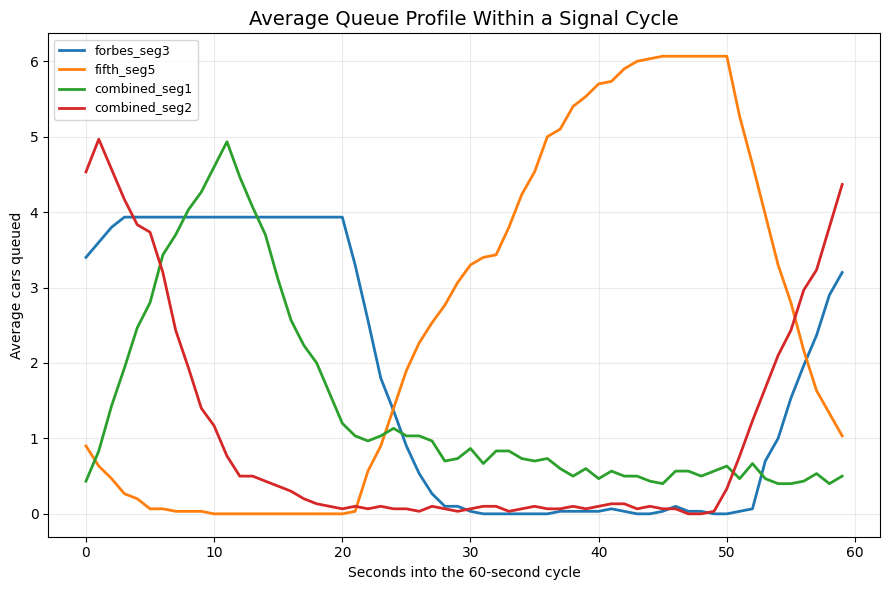

In [5]:
KEY_SEGMENTS = ["forbes_seg3", "fifth_seg5", "combined_seg1", "combined_seg2"]

queue_df["cycle_position"] = queue_df.index % CYCLE_LENGTH_S
cyclic_profile = queue_df.groupby("cycle_position")[KEY_SEGMENTS].mean()

fig, ax = plt.subplots(figsize=(9, 6))
for seg in KEY_SEGMENTS:
    ax.plot(cyclic_profile.index, cyclic_profile[seg], label=seg, linewidth=2)

ax.set_title("Average Queue Profile Within a Signal Cycle", fontsize=14)
ax.set_xlabel("Seconds into the 60-second cycle")
ax.set_ylabel("Average cars queued")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("eda_viz1_cyclic_profile.png", dpi=200, bbox_inches="tight")
plt.show()


## Visual 2: Mean congestion by segment, with the green-ratio fix visible

Ranking every segment by its average queue length, colored by whether it's a mainline (avenue) segment or a cross street, and annotated with each controlling intersection's green ratio. If the 80/20 fix at Stanwix St and Fort Pitt Bridge actually worked, their mainline segments (`combined_seg1`, `combined_seg2`) should sit noticeably lower than the still-50/50 segments right before the merge (`forbes_seg3`, `fifth_seg5`) -- despite carrying the *combined* volume of both avenues.

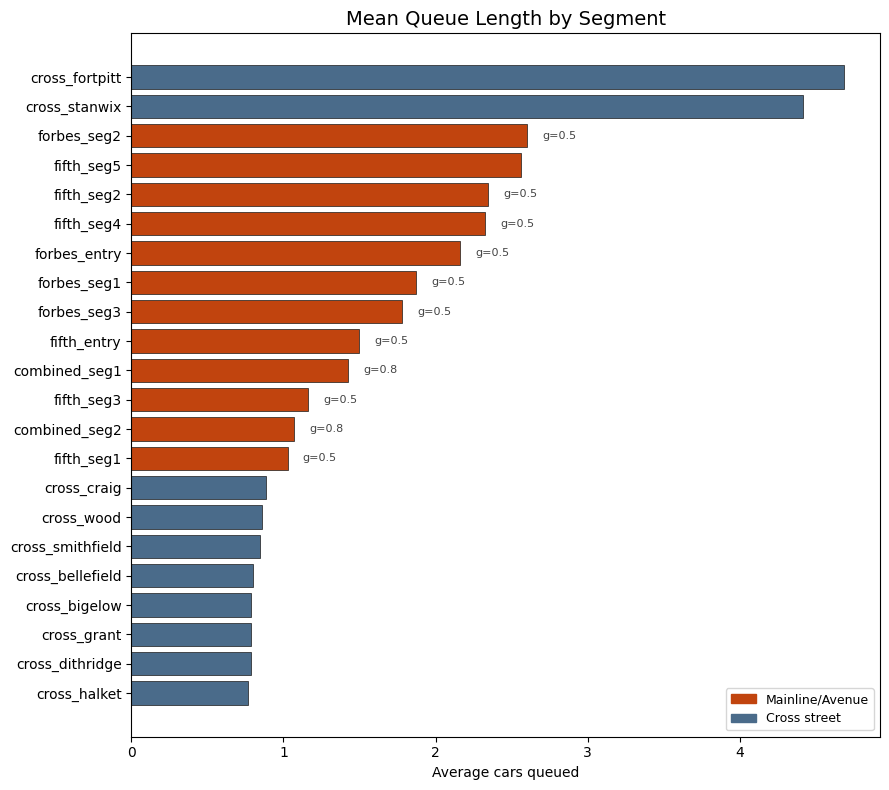

In [6]:
# Map each edge to its controlling intersection's green ratio (approach 0 = mainline)
edge_to_green_ratio = dict(zip(network_df["approach_0_edge_in"], network_df["green_ratio_0"]))

plot_df = summary.reset_index().rename(columns={"index": "segment"})
plot_df = plot_df[plot_df["segment"] != "cycle_position"]
plot_df["type"] = plot_df["segment"].apply(lambda s: "Cross street" if s.startswith("cross_") else "Mainline/Avenue")
plot_df["green_ratio"] = plot_df["segment"].map(edge_to_green_ratio)
plot_df = plot_df.sort_values("mean_queue", ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
colors = plot_df["type"].map({"Mainline/Avenue": MAINLINE_COLOR, "Cross street": CROSS_COLOR})
ax.barh(plot_df["segment"], plot_df["mean_queue"], color=colors, edgecolor=PGH_BLACK, linewidth=0.5)

for i, (seg, gr) in enumerate(zip(plot_df["segment"], plot_df["green_ratio"])):
    if pd.notna(gr):
        ax.text(plot_df["mean_queue"].iloc[i] + 0.1, i, f"g={gr:.1f}", va="center", fontsize=8, color="#444")

handles = [plt.Rectangle((0,0),1,1, color=MAINLINE_COLOR), plt.Rectangle((0,0),1,1, color=CROSS_COLOR)]
ax.legend(handles, ["Mainline/Avenue", "Cross street"], loc="lower right", fontsize=9)
ax.set_title("Mean Queue Length by Segment", fontsize=14)
ax.set_xlabel("Average cars queued")
plt.tight_layout()
plt.savefig("eda_viz2_mean_queue_by_segment.png", dpi=200, bbox_inches="tight")
plt.show()


## Did the fix actually work?

A direct check: compare mean queue on the two pre-merge mainline segments (still 50/50) against the two post-merge segments (80/20), which carry the combined volume of both avenues.

In [7]:
pre_merge = summary.loc[["forbes_seg3", "fifth_seg5"], "mean_queue"].mean()
post_merge = summary.loc[["combined_seg1", "combined_seg2"], "mean_queue"].mean()

print(f"Mean queue, pre-merge segments (50/50 split, single-avenue volume):  {pre_merge:.2f}")
print(f"Mean queue, post-merge segments (80/20 split, combined volume):     {post_merge:.2f}")
print()
if post_merge <= pre_merge:
    print("The post-merge segments carry MORE traffic but show similar or LOWER average queueing --")
    print("consistent with the 80/20 green-ratio fix doing its job.")
else:
    print("The post-merge segments still show higher average queueing than pre-merge --")
    print("worth revisiting the green-ratio assumption if this matters for later projects.")


Mean queue, pre-merge segments (50/50 split, single-avenue volume):  2.17
Mean queue, post-merge segments (80/20 split, combined volume):     1.25

The post-merge segments carry MORE traffic but show similar or LOWER average queueing --
consistent with the 80/20 green-ratio fix doing its job.


## Save the two visuals

In [8]:
from google.colab import files

files.download("eda_viz1_cyclic_profile.png")
files.download("eda_viz2_mean_queue_by_segment.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Recap

Two subject-specific views on top of the simulation output: the average within-cycle queue profile (the standard traffic-engineering "sawtooth"), and a direct, data-backed check on whether the green-ratio fix from the simulation notebook actually holds up -- rather than just trusting the earlier reasoning. Both are quick, both are grounded in the actual run, and neither required re-running the simulation.